## Retail Demand Forecasting & Inventory Insights – Feature Engineering & EDA

#### Objective

To explore sales patterns, understand revenue drivers, and engineer meaningful features that support business insights and downstream analytics.

### Importing Libraries

In [ ]:
import pandas as pd #import pandas for data handling
import numpy as np #import numpy for mathematical calculations
import matplotlib.pyplot as plt #import matplotlib for graphs
import seaborn as sns #import seaborn for graphs

###Loading the dataset

In [ ]:
df=pd.read_csv("cleaned_BrightMart_retail_dataset.csv")
df.head()

,Category,Item,Price Per Unit,Quantity,Payment Method,Location,Transaction Date,Discount Applied,Season,Month,Weekday,Stock On Hand,Promotion,Revenue
0,Patisserie,Item_10_Pat,18.5,10.0,Digital Wallet,Online,2024-04-08,True,Spring,April,Monday,152,10,166.50
1,Milk Products,Item_17_Milk,29.0,9.0,Digital Wallet,Online,2023-07-23,True,Summer,July,Sunday,142,10,234.90
2,Butchers,Item_12_But,21.5,2.0,Credit Card,Online,2022-10-05,True,Fall,October,Wednesday,64,10,38.70
3,Beverages,Item_16_Bev,27.5,9.0,Credit Card,Online,2022-05-07,True,Spring,May,Saturday,156,10,222.75
4,Food,Item_6_Food,12.5,7.0,Digital Wallet,Online,2022-10-02,False,Fall,October,Sunday,121,0,87.50


### Checking and verifying the data

In [ ]:
df.info() #getting the overall information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          12575 non-null  object 
 1   Item              12575 non-null  object 
 2   Price Per Unit    12575 non-null  float64
 3   Quantity          12575 non-null  float64
 4   Payment Method    12575 non-null  object 
 5   Location          12575 non-null  object 
 6   Transaction Date  12575 non-null  object 
 7   Discount Applied  12575 non-null  bool   
 8   Season            12575 non-null  object 
 9   Month             12575 non-null  object 
 10  Weekday           12575 non-null  object 
 11  Stock On Hand     12575 non-null  int64  
 12  Promotion         12575 non-null  int64  
 13  Revenue           12575 non-null  float64
dtypes: bool(1), float64(3), int64(2), object(8)
memory usage: 1.3+ MB


#### Transcation Date needs to be in datetime format

In [ ]:
df['Transaction Date']= pd.to_datetime(df['Transaction Date']) #converting transcation date column into date time format

#### Dataset loaded successfully. Transaction Date converted to datetime for time-based analysis.

### Feature Engineering – Time Based Features

In [ ]:
df['Year']= df['Transaction Date'].dt.year #extracting the year
df['Month Num']= df['Transaction Date'].dt.month #extracting the number of month
df['Day']= df['Transaction Date'].dt.day #extracting the number of day
df['Week Num']= df['Transaction Date'].dt.isocalendar().week #extracting the number of week
# These features help capture yearly trends, monthly seasonality, and weekly demand patterns.

,Category,Item,Price Per Unit,Quantity,Payment Method,Location,Transaction Date,Discount Applied,Season,Month,Weekday,Stock On Hand,Promotion,Revenue,Year,Month Num,Day,Week Num
0,Patisserie,Item_10_Pat,18.5,10.0,Digital Wallet,Online,2024-04-08,True,Spring,April,Monday,152,10,166.50,2024,4,8,15
1,Milk Products,Item_17_Milk,29.0,9.0,Digital Wallet,Online,2023-07-23,True,Summer,July,Sunday,142,10,234.90,2023,7,23,29
2,Butchers,Item_12_But,21.5,2.0,Credit Card,Online,2022-10-05,True,Fall,October,Wednesday,64,10,38.70,2022,10,5,40
3,Beverages,Item_16_Bev,27.5,9.0,Credit Card,Online,2022-05-07,True,Spring,May,Saturday,156,10,222.75,2022,5,7,18
4,Food,Item_6_Food,12.5,7.0,Digital Wallet,Online,2022-10-02,False,Fall,October,Sunday,121,0,87.50,2022,10,2,39


### Business KPI Creation
- Total Revenue
- Average Order Value
- Units sold
- Promotion Impact

In [ ]:
df['Average Order Value']= df['Revenue']/df['Quantity']
df['Promotion Impact']= (df['Price Per Unit']*df['Quantity'])-df['Revenue']
df['Promotion Impact Per Unit']= df['Price Per Unit']-(df['Revenue']/df['Quantity'])

#### df['Promotion Impact Per Unit'] Shows how much discount the customer got in each transaction. Calculated as the difference between original price and revenue per unit.

#### df['Promotion Impact'] Shows how much total discount the customer got. Calculated as the difference between the original price- disconted price.

#### df['Average Order Value'] Shows Average price paid per unit after promotions. This reflects what the customer actually paid per unit, not the original price.

### EDA – Overall Business Performance

#### Total Revenue Over Time
Revenue shows clear seasonality, indicating demand fluctuations across months.

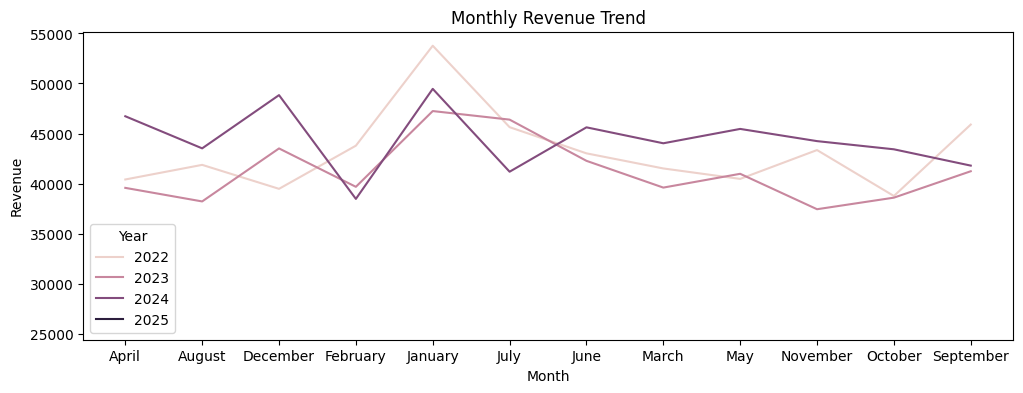

In [ ]:
monthly_revenue= df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
plt.figure(figsize=(12,4))
sns.lineplot(data= monthly_revenue, x='Month', y='Revenue', hue='Year')
plt.title("Monthly Revenue Trend")
plt.show()

#### Insights:
- Revenue fluctuates month-to-month across years 2022–2025.

- Some months (e.g., January to July) show clear revenue spikes, which could be due to seasonal demand, holidays, or promotions.

- The trends appear consistent across years, indicating recurring seasonal patterns.

#### Business Recommendations:
- Plan promotions and inventory ahead of months with high revenue to maximize sales and reduce stockouts.

- Use historical trends to forecast demand for upcoming months.

- Consider targeted marketing campaigns in low-revenue months to balance sales throughout the year.

### Category-Level Analysis
Which categories drive the most revenue?

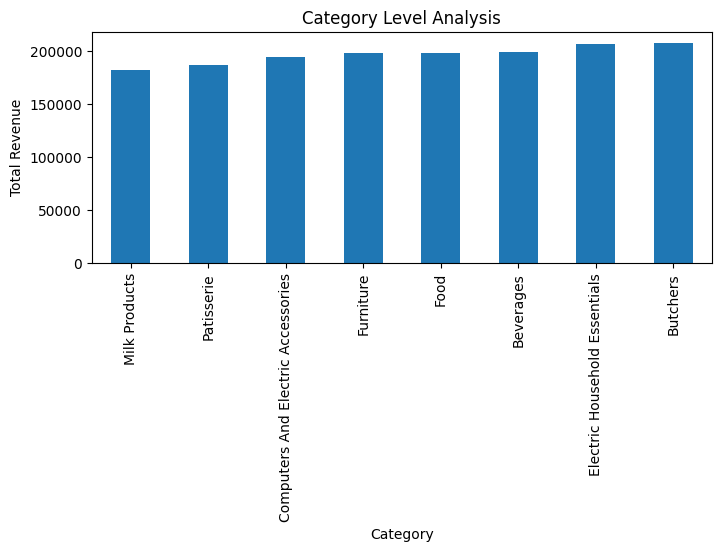

In [ ]:
category_revenue= df.groupby('Category')['Revenue'].sum().sort_values(ascending=True)
plt.figure(figsize=(8,3))
category_revenue.plot(kind='bar')
plt.title("Category Level Analysis")
plt.ylabel('Total Revenue')
plt.show()

#### Insights
- Revenue is relatively balanced across most categories, with Food, Beverages, and Household Essentials and Butchers slightly higher.

- Lower revenue in categories like Electronic Accessories or Furniture may be due to fewer transactions.

#### Recommendations:
- Focus marketing and inventory planning on top-performing categories (Household Essentials, Beverages, and food) to maintain growth.

- Investigate underperforming categories (Furniture, Accessories) – improve visibility, promotions, or bundle offers.

- Consider category-specific promotions to balance sales across all categories.

#### Promotion Impact Analysis
Promotions significantly impact transaction value and should be optimized strategically.

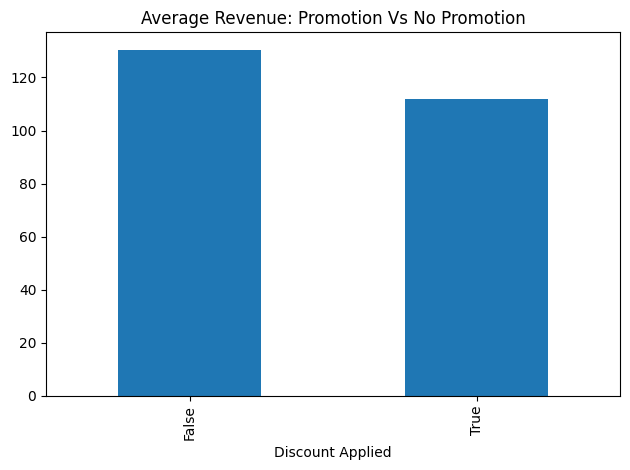

In [ ]:
promotion_analysis= df.groupby('Discount Applied')['Revenue'].mean()
promotion_analysis.plot(kind='bar')
plt.title("Average Revenue: Promotion Vs No Promotion")
plt.tight_layout()
plt.show()

#### Insights
- Products sold with a promotion (discount applied) have slightly lower average revenue compared to those sold without a promotion.

#### Business Recommendations:
- Use promotions strategically on slow-moving items or during low-revenue months to boost sales volume.

- Avoid heavy discounts on high-demand items to preserve revenue.

#### Stock vs Sales Relationship
Low stock levels may limit sales potential, increasing risk of lost revenue.

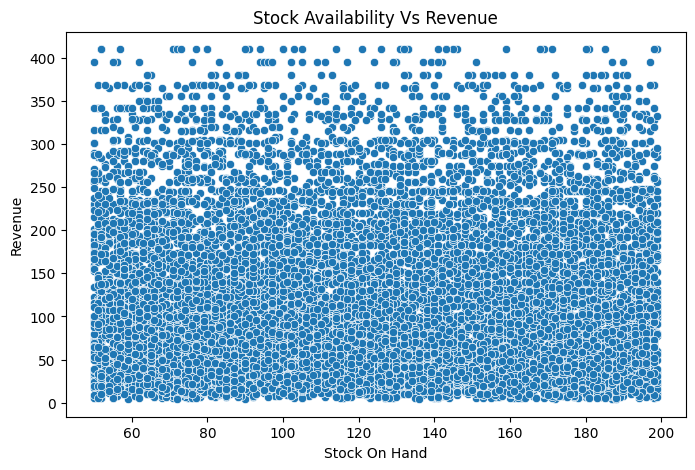

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Stock On Hand", y="Revenue")
plt.title("Stock Availability Vs Revenue")
plt.show()

#### Insights:
- Revenue does not strongly correlate with stock-on-hand; dots are widely spread.

- This suggests that simply having more stock does not guarantee higher revenue.

- Outliers indicate some high-priced items or bulk purchases generating very high revenue even with moderate stock.

#### Business Insights:
- Optimize inventory based on forecasted demand rather than just quantity in stock.

- Use predictive models to ensure high-demand products are available, avoiding stockouts.

- Monitor high-revenue items closely to prevent overstock and financial losses.

#### Day-of-Week Sales Pattern
Certain weekdays consistently outperform others, useful for staffing and promotions.

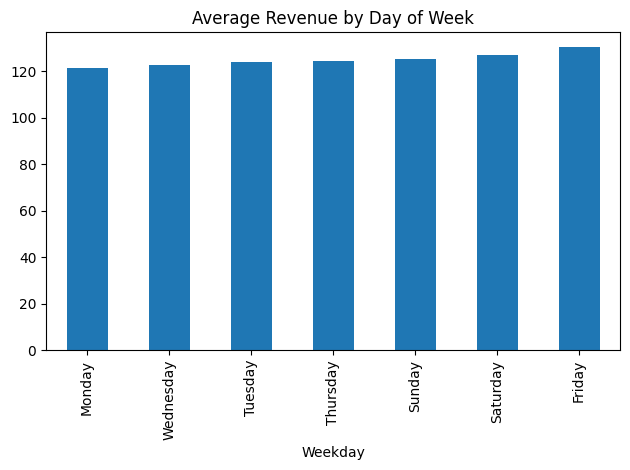

In [ ]:
weekday_sales= df.groupby("Weekday")['Revenue'].mean().sort_values()
weekday_sales.plot(kind='bar')
plt.title("Average Revenue by Day of Week")
plt.tight_layout()
plt.show()

#### Insights:
- Revenue is fairly consistent across all days

- Slight increase towards weekends, especially Saturday & Friday

- No extreme peaks or drops → stable consumer behavior

#### Business Recommendation:
- Maintain consistent inventory levels throughout the week

- Run weekend-specific promotions:

           Flash deals

           Bundles

- Schedule marketing campaigns mid-week to push traffic toward weekends

In [ ]:
df.columns

Index(['Category', 'Item', 'Price Per Unit', 'Quantity', 'Payment Method',
       'Location', 'Transaction Date', 'Discount Applied', 'Season', 'Month',
       'Weekday', 'Stock On Hand', 'Promotion', 'Revenue', 'Year', 'Month Num',
       'Day', 'Week Num', 'Average Order Value', 'Promotion Impact',
       'Promotion Impact Per Unit'],
      dtype='object')

#### Season Vs Revenue

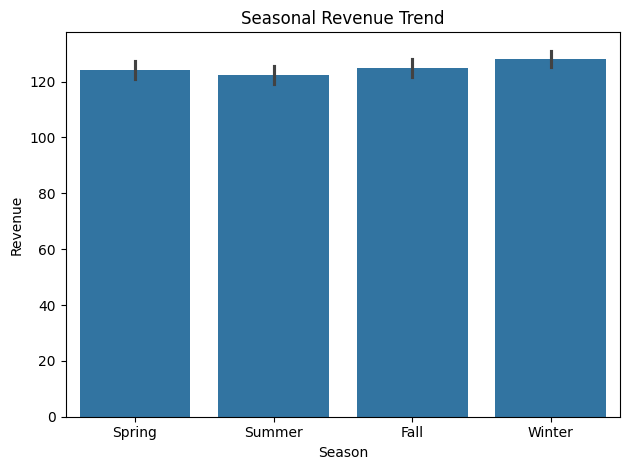

In [ ]:
sns.barplot(data=df, x='Season', y='Revenue')
plt.title("Seasonal Revenue Trend")
plt.tight_layout()
plt.show()

#### Insights:
- Revenue is consistent across all seasons

- Slightly higher in Fall & Winter

- Indicates non-seasonal product portfolio

#### Business Recommendations:
- Since demand is stable:

  Focus on operational efficiency rather than seasonal stockpiling

- Introduce seasonal limited editions in Fall/Winter to amplify existing peaks

#### Revenue By Payment Method

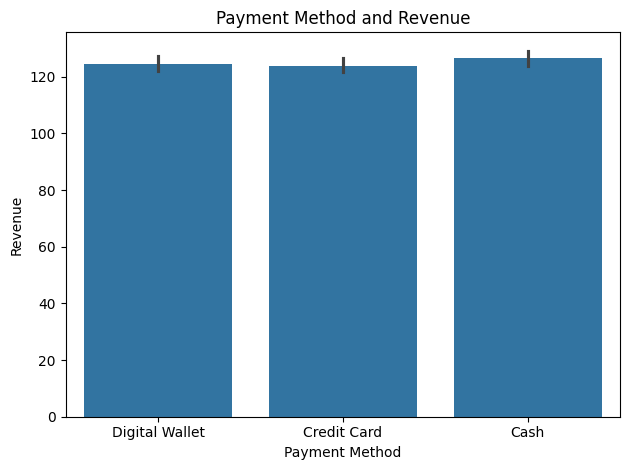

In [ ]:
sns.barplot(data=df, x='Payment Method', y='Revenue')
plt.title("Payment Method and Revenue")
plt.tight_layout()
plt.show()

#### Insights
- All payment methods generate nearly equal revenue

- Slight edge for digital wallets

- Indicates customer payment flexibility and adoption of cashless options

#### Business Recommendations:
- Promote digital wallets:

          Cashback

          Loyalty points

- This can:

        Reduce cash handling costs

        Improve checkout speed

- Maintain multiple payment options — no need to eliminate cash yet

#### Revenue by Location

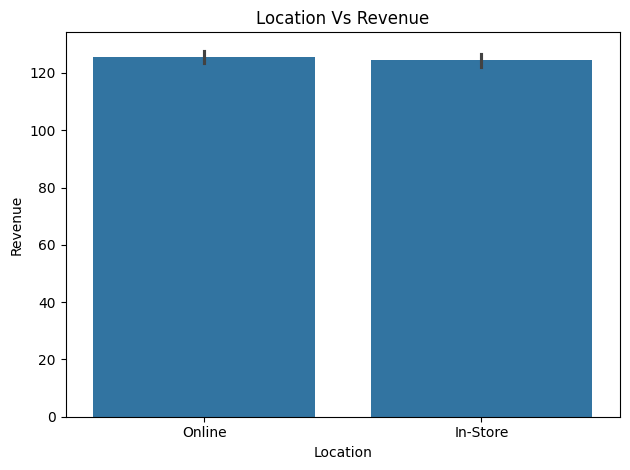

In [ ]:
sns.barplot(data=df, x='Location', y='Revenue')
plt.title("Location Vs Revenue")
plt.tight_layout()
plt.show()

#### Insights:
- Online and in-store revenues are nearly equal

- Strong omnichannel presence

- Customers are comfortable shopping on both platforms

Business Recommendations:
- Invest equally in online & physical channels

- Use cross-channel strategies:

    Buy online, pick up in-store

    In-store QR codes for online discounts

- Track customer journey across channels to personalize offers

#### Item-Level Top Sellers

Identify top 10 items by revenue or units sold.

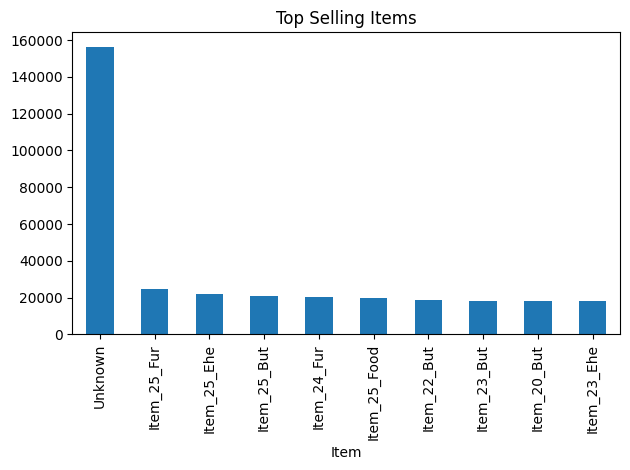

In [ ]:
top_sellers= df.groupby('Item')['Revenue'].sum().sort_values(ascending=False).head(10)
top_sellers.plot(kind='bar')
plt.title("Top Selling Items")
plt.tight_layout()
plt.show()

#### Insights:
- items show long-tail distribution — many items with moderate sales.

##### Business Recommendations:
- Immediately investigate “Unknown” item

            Could be:

            POS tagging error

            Popular bundle incorrectly labeled

- Fixing this can:

             Improve demand forecasting

             Enable better pricing & promotion strategies
- Bundle low-performing items with top sellers to increase basket size

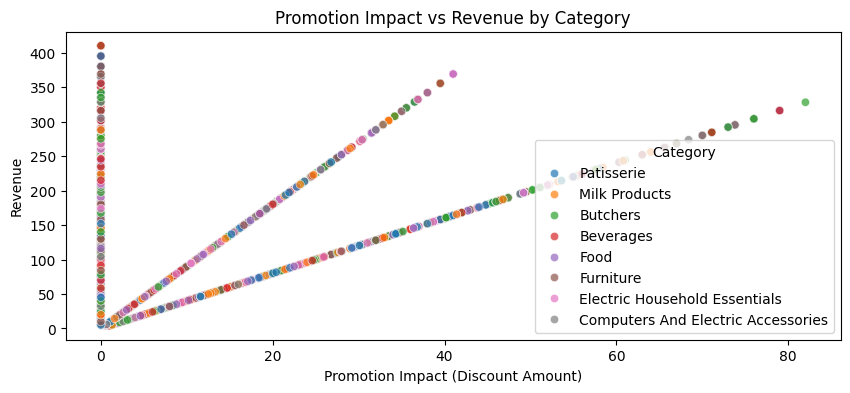

In [ ]:
plt.figure(figsize=(10,4))
sns.scatterplot(data=df, x='Promotion Impact', y='Revenue', hue='Category', alpha=0.7)
plt.title('Promotion Impact vs Revenue by Category')
plt.xlabel('Promotion Impact (Discount Amount)')
plt.ylabel('Revenue')
plt.show()

#### Insights:
- Clear positive correlation: As promotion discounts increase, revenue increases across most categories.

- Food & Beverages respond strongest to promotions — steep upward trend.

- Electronics & Household Essentials also respond well, but need higher discounts to achieve the same revenue lift.

- Some categories show diminishing returns at higher discounts — revenue growth flattens.

####Recommendations:
- Prioritize promotions for Food & Beverages
Food and Beverage categories show higher revenue sensitivity to discounts, achieving larger revenue lifts at lower discount levels compared to other categories.

- Use targeted, higher discounts for Electronics
Instead of blanket discounts, apply promotions during:

             Festive seasons

             Clearance sales

- Set discount caps
Avoid excessive discounts where revenue growth is already high — this protects margins.

### Summary of Exploratory Data Analysis
- Analyzed revenue distribution, promotions, time trends, product performance, payment methods, and sales channels

- Identified positive relationship between discounts and revenue with category-level variation

- Confirmed stable demand across weekdays and seasons

- Detected outliers and anomalies, including a high-selling “Unknown” product

- Compared online vs in-store and payment method behavior to assess customer preferences
- Revenue Trends Over Time: Analyzed monthly and yearly revenue patterns to identify seasonality and growth trends.

- Category-Level Performance: Compared total revenue across product categories to identify top and underperforming segments.

- Promotion vs Non-Promotion Analysis: Evaluated the impact of discounts on revenue to assess promotion effectiveness.

- Season, Location, and Payment Method Analysis: Studied how revenue varies across seasons, sales channels (online vs in-store), and payment methods.

- Inventory vs Revenue Relationship: Examined the relationship between stock availability and revenue generation.
- Revenue shows seasonal fluctuations, with certain months consistently performing better.

- Core categories such as Food, Beverages, and Essentials contribute the most to revenue.
- Promotions slightly reduce average revenue per order but help increase sales volume.

- High stock levels do not directly guarantee higher revenue, indicating demand-driven sales.

### Summary of Feature Engineering
- Created aggregated revenue and sales metrics for trend analysis

- Engineered promotion-related features to measure discount impact

- Extracted time-based features (day of week, season) from transaction dates

- Grouped and standardized product categories for consistent analysis

- Prepared channel and payment method features for comparative insights
Key Analyses Performed
- Enable better KPI tracking (AOV, units sold, promotion effectiveness).

- Support business decision-making around pricing, promotions, and inventory planning.

- Prepare the dataset for advanced analytics and predictive modeling.